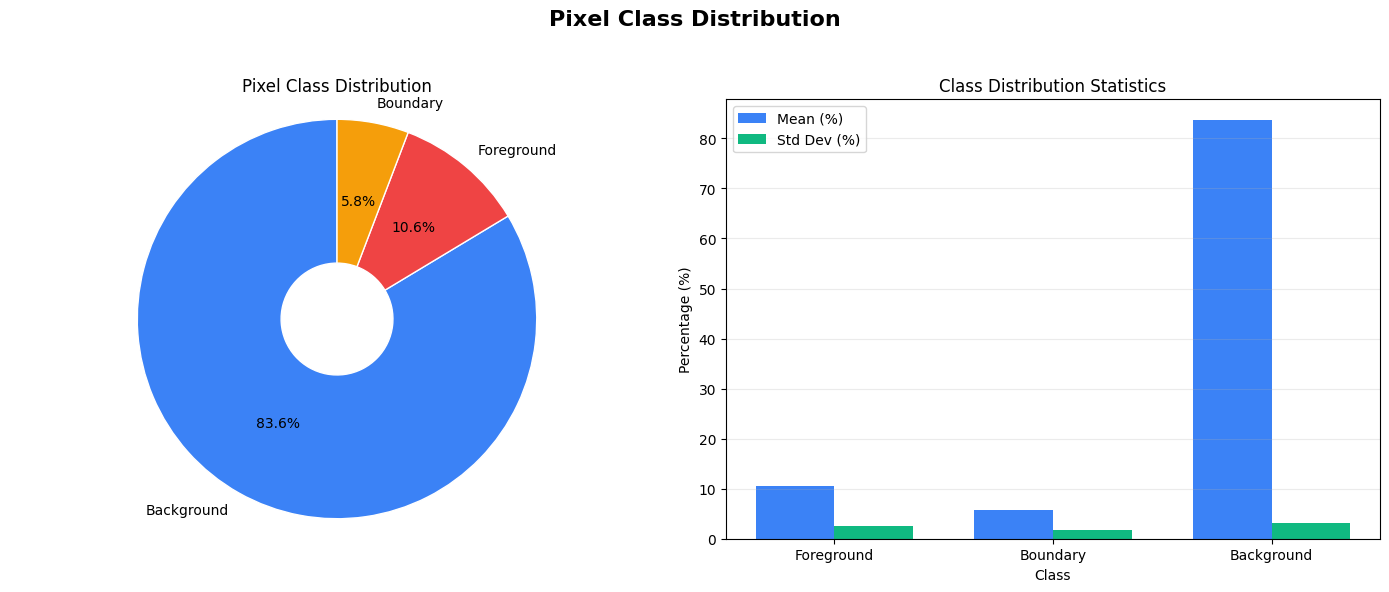

Loaded 200 breeds from csv\pixel_distribution.csv
Foreground: mean=10.58% | std=2.47%
Boundary: mean=5.80% | std=1.77%
Background: mean=83.63% | std=3.17%


In [2]:
"""CUB Pixel Class Summary - Matplotlib
Data: local csv/pixel_distribution.csv
"""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("csv/pixel_distribution.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

df = pd.read_csv(csv_path)

required_cols = [
    "fg_percentage_mean",
    "boundary_percentage_mean",
    "bg_percentage_mean",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

# Aggregate class-level summary across breeds.
classes = ["Foreground", "Boundary", "Background"]
mean_cols = ["fg_percentage_mean", "boundary_percentage_mean", "bg_percentage_mean"]
class_means = [float(df[c].mean()) for c in mean_cols]
class_stds = [float(df[c].std(ddof=0)) for c in mean_cols]

# Keep pie chart percentages normalized to exactly 100%.
total_mean = sum(class_means)
if total_mean > 0:
    pie_vals = [v * 100.0 / total_mean for v in class_means]
else:
    pie_vals = [0.0, 0.0, 0.0]

colors = {
    "Background": "#3b82f6",
    "Foreground": "#ef4444",
    "Boundary": "#f59e0b",
}
pie_order = ["Background", "Foreground", "Boundary"]

mean_map = dict(zip(classes, class_means))
std_map = dict(zip(classes, class_stds))
pie_map = dict(zip(classes, pie_vals))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Pixel Class Distribution", fontsize=16, fontweight="bold")

# 1) Donut chart: average class composition.
labels = pie_order
sizes = [pie_map[k] for k in labels]
pie_colors = [colors[k] for k in labels]
wedges, texts, autotexts = axes[0].pie(
    sizes,
    labels=labels,
    colors=pie_colors,
    startangle=90,
    autopct="%.1f%%",
    wedgeprops={"width": 0.72, "edgecolor": "white"},
    textprops={"fontsize": 10},
)
axes[0].set_title("Pixel Class Distribution")
axes[0].axis("equal")

# 2) Grouped bars: mean and std by class.
x = np.arange(len(classes))
bar_w = 0.36
axes[1].bar(
    x - bar_w / 2,
    [mean_map[k] for k in classes],
    width=bar_w,
    color="#3b82f6",
    label="Mean (%)",
)
axes[1].bar(
    x + bar_w / 2,
    [std_map[k] for k in classes],
    width=bar_w,
    color="#10b981",
    label="Std Dev (%)",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Class Distribution Statistics")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"Loaded {len(df):,} breeds from {csv_path}")
for k in classes:
    print(f"{k}: mean={mean_map[k]:.2f}% | std={std_map[k]:.2f}%")

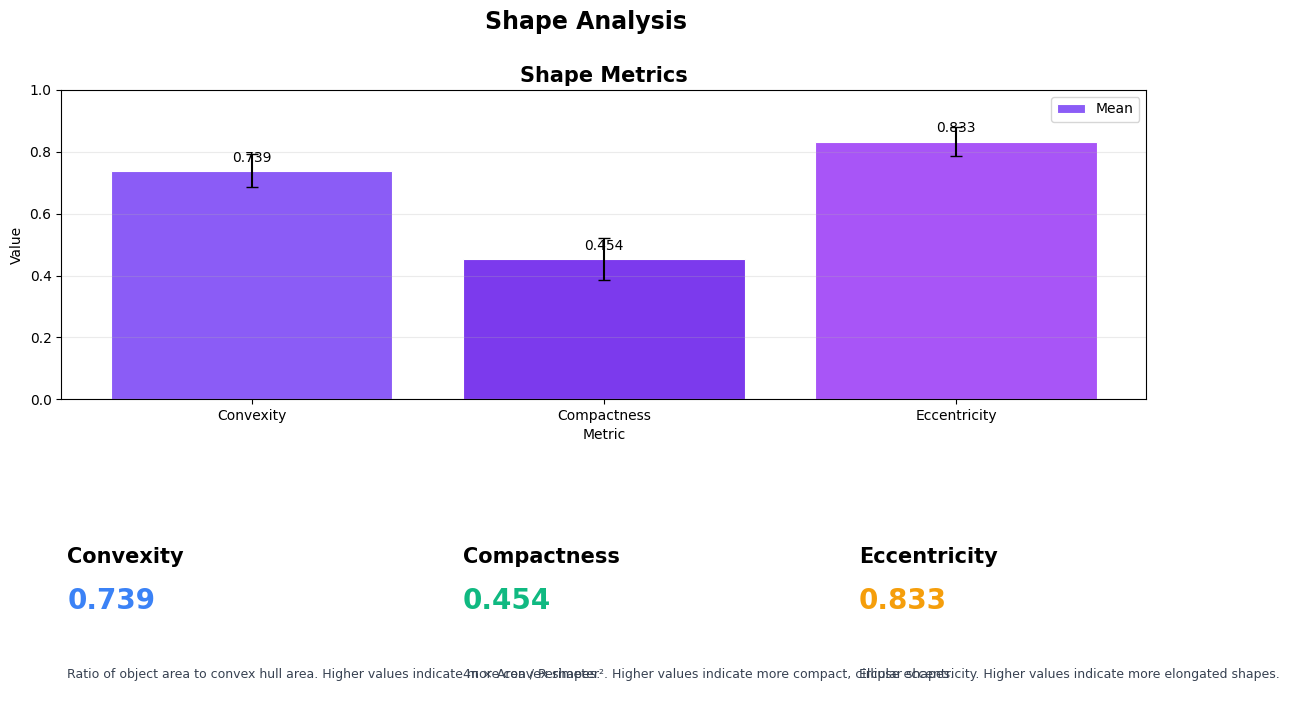

Loaded 200 breeds from csv\shape_distribution.csv
Convexity: mean=0.739 | std=0.053
Compactness: mean=0.454 | std=0.069
Eccentricity: mean=0.833 | std=0.048


In [3]:
"""CUB Shape Analysis - Matplotlib
Data: local csv/shape_distribution.csv
"""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("csv/shape_distribution.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

df_shape = pd.read_csv(csv_path)
required_cols = [
    "convexity_mean",
    "compactness_mean",
    "eccentricity_mean",
]
missing = [c for c in required_cols if c not in df_shape.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

metrics = ["Convexity", "Compactness", "Eccentricity"]
mean_cols = ["convexity_mean", "compactness_mean", "eccentricity_mean"]

means = [float(df_shape[c].mean()) for c in mean_cols]
stds = [float(df_shape[c].std(ddof=0)) for c in mean_cols]

# Main chart + metric cards layout.
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[3.2, 1.8], hspace=0.55, wspace=0.35)

ax = fig.add_subplot(gs[0, :])
x = np.arange(len(metrics))

bars = ax.bar(
    x,
    means,
    yerr=stds,
    capsize=4,
    color=["#8b5cf6", "#7c3aed", "#a855f7"],
    edgecolor="white",
    linewidth=0.8,
    label="Mean",
)
ax.set_title("Shape Metrics", fontsize=15, fontweight="bold")
ax.set_ylabel("Value")
ax.set_xlabel("Metric")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, min(1.0, max(means) + max(stds) + 0.15))
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")

for i, bar in enumerate(bars):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{means[i]:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

card_titles = ["Convexity", "Compactness", "Eccentricity"]
card_desc = [
    "Ratio of object area to convex hull area. Higher values indicate more convex shapes.",
    "4π × Area / Perimeter². Higher values indicate more compact, circular shapes.",
    "Ellipse eccentricity. Higher values indicate more elongated shapes.",
]
card_colors = ["#3b82f6", "#10b981", "#f59e0b"]

for i in range(3):
    ax_card = fig.add_subplot(gs[1, i])
    ax_card.axis("off")
    ax_card.text(0.02, 0.82, card_titles[i], fontsize=15, fontweight="bold")
    ax_card.text(
        0.02,
        0.56,
        f"{means[i]:.3f}",
        fontsize=20,
        fontweight="bold",
        color=card_colors[i],
    )
    ax_card.text(0.02, 0.16, card_desc[i], fontsize=9, color="#374151", wrap=True)

fig.suptitle("Shape Analysis", fontsize=17, fontweight="bold", y=0.98)
plt.show()

print(f"Loaded {len(df_shape):,} breeds from {csv_path}")
for name, mean_val, std_val in zip(metrics, means, stds):
    print(f"{name}: mean={mean_val:.3f} | std={std_val:.3f}")

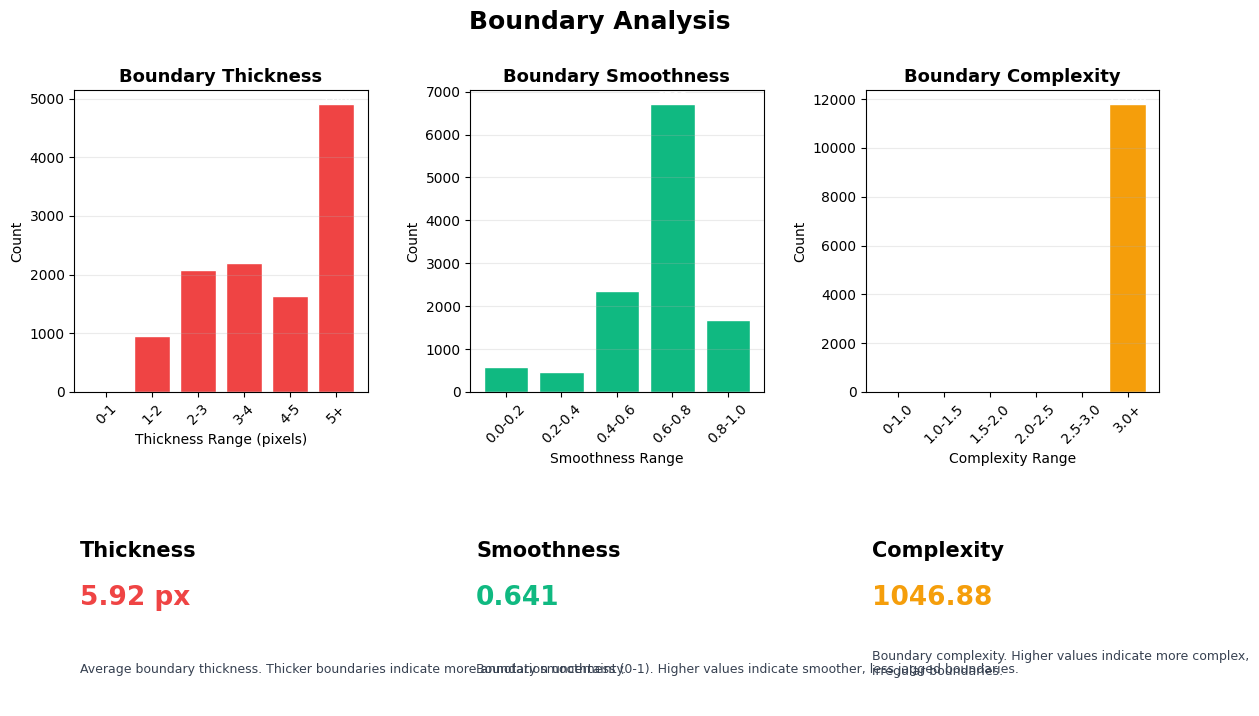

Loaded 11,788 masks from csv\mask_statistics.csv
Thickness mean: 5.92 px
Smoothness mean: 0.641
Complexity mean: 1046.88


In [4]:
"""CUB Boundary Analysis - Matplotlib
Data: local csv/mask_statistics.csv
"""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("csv/mask_statistics.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

df_boundary = pd.read_csv(csv_path)
required_cols = [
    "boundary_pixels",
    "fg_pixels",
    "mask_height",
    "mask_width",
]
missing = [c for c in required_cols if c not in df_boundary.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

# Derived boundary metrics per mask.
eps = 1e-9
img_perimeter = 2.0 * (df_boundary["mask_height"] + df_boundary["mask_width"])
boundary_thickness = df_boundary["boundary_pixels"] / np.maximum(img_perimeter, eps)
boundary_smoothness = 1.0 - (df_boundary["boundary_pixels"] / np.maximum(df_boundary["fg_pixels"] + df_boundary["boundary_pixels"], eps))
boundary_complexity = df_boundary["boundary_pixels"] / np.maximum(np.sqrt(df_boundary["fg_pixels"]), 1.0)

boundary_smoothness = boundary_smoothness.clip(0.0, 1.0)

# Binned distributions for dashboard-style bars.
th_bins = [0, 1, 2, 3, 4, 5, np.inf]
th_labels = ["0-1", "1-2", "2-3", "3-4", "4-5", "5+"]
sm_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
sm_labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
cx_bins = [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, np.inf]
cx_labels = ["0-1.0", "1.0-1.5", "1.5-2.0", "2.0-2.5", "2.5-3.0", "3.0+"]

th_counts = pd.cut(boundary_thickness, bins=th_bins, labels=th_labels, include_lowest=True).value_counts().reindex(th_labels, fill_value=0)
sm_counts = pd.cut(boundary_smoothness, bins=sm_bins, labels=sm_labels, include_lowest=True).value_counts().reindex(sm_labels, fill_value=0)
cx_counts = pd.cut(boundary_complexity, bins=cx_bins, labels=cx_labels, include_lowest=True).value_counts().reindex(cx_labels, fill_value=0)

th_mean = float(boundary_thickness.mean())
sm_mean = float(boundary_smoothness.mean())
cx_mean = float(boundary_complexity.mean())

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[3.0, 1.8], hspace=0.55, wspace=0.35)

# Top row: three distributions.
top_titles = ["Boundary Thickness", "Boundary Smoothness", "Boundary Complexity"]
counts_list = [th_counts, sm_counts, cx_counts]
bar_colors = ["#ef4444", "#10b981", "#f59e0b"]
xlabels = ["Thickness Range (pixels)", "Smoothness Range", "Complexity Range"]

for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    vals = counts_list[i].values
    bars = ax.bar(counts_list[i].index.astype(str), vals, color=bar_colors[i], edgecolor="white")
    ax.set_title(top_titles[i], fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xlabel(xlabels[i])
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=45)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(v)}", ha="center", va="bottom", fontsize=9, color="white")

# Bottom row: metric cards.
card_titles = ["Thickness", "Smoothness", "Complexity"]
card_values = [f"{th_mean:.2f} px", f"{sm_mean:.3f}", f"{cx_mean:.2f}"]
card_desc = [
    "Average boundary thickness. Thicker boundaries indicate more annotation uncertainty.",
    "Boundary smoothness (0-1). Higher values indicate smoother, less jagged boundaries.",
    "Boundary complexity. Higher values indicate more complex, irregular boundaries.",
]
card_colors = ["#ef4444", "#10b981", "#f59e0b"]

for i in range(3):
    ax_card = fig.add_subplot(gs[1, i])
    ax_card.axis("off")
    ax_card.text(0.02, 0.82, card_titles[i], fontsize=15, fontweight="bold")
    ax_card.text(0.02, 0.56, card_values[i], fontsize=19, fontweight="bold", color=card_colors[i])
    ax_card.text(0.02, 0.18, card_desc[i], fontsize=9, color="#374151", wrap=True)

fig.suptitle("Boundary Analysis", fontsize=18, fontweight="bold", y=0.98)
plt.show()

print(f"Loaded {len(df_boundary):,} masks from {csv_path}")
print(f"Thickness mean: {th_mean:.2f} px")
print(f"Smoothness mean: {sm_mean:.3f}")
print(f"Complexity mean: {cx_mean:.2f}")

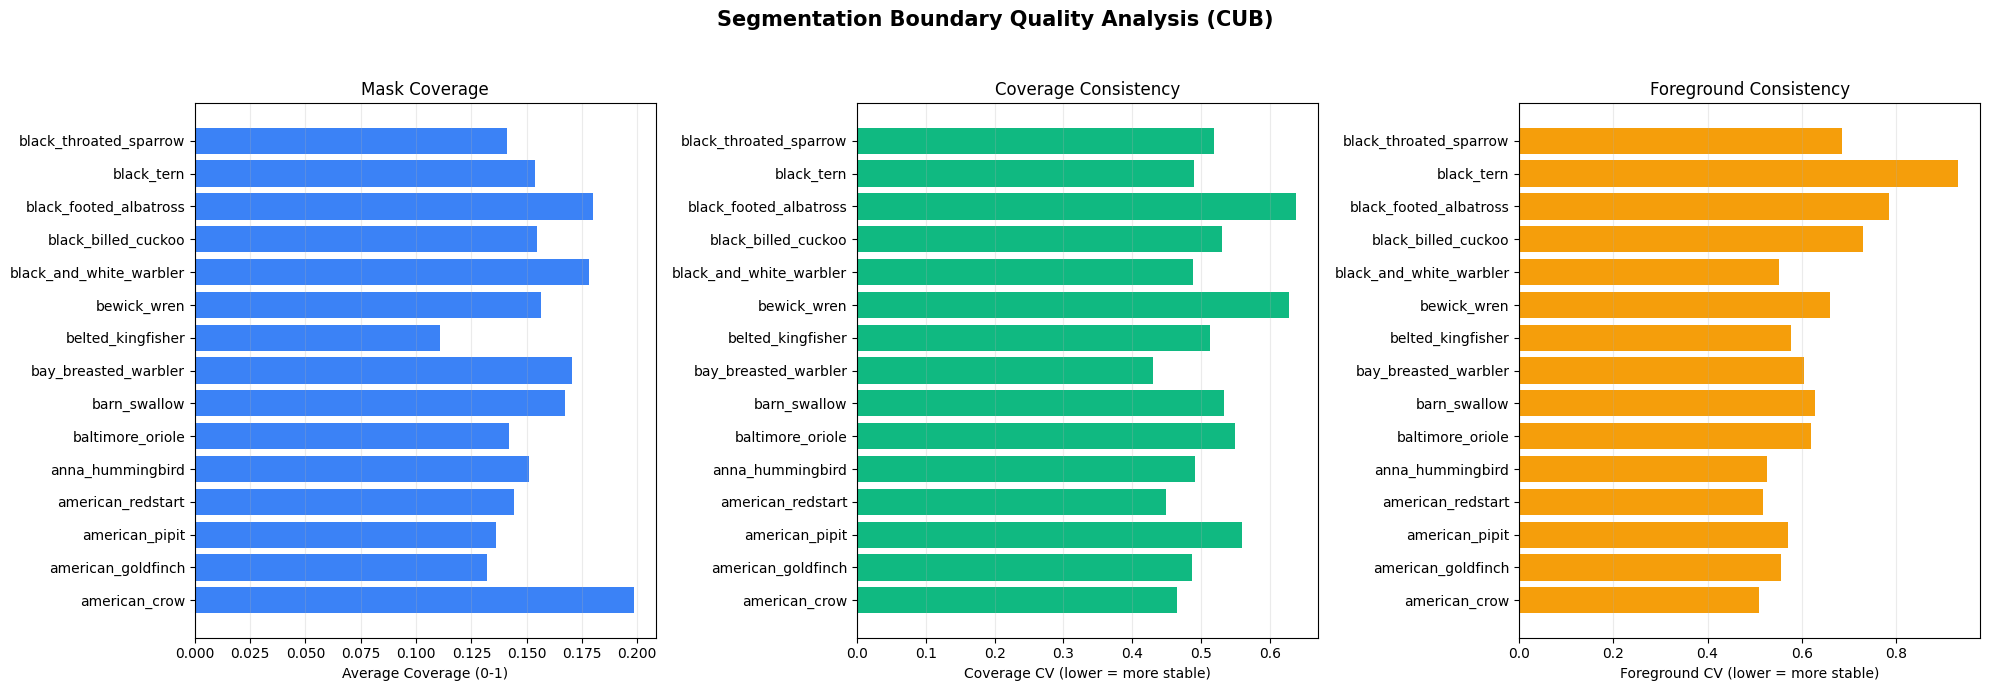

Loaded 200 breeds from csv\segmentation_boundary_quality_metric.csv
Overall avg_coverage mean: 0.164
Overall coverage_cv mean: 0.505
Overall fg_cv mean: 0.616
Overall avg_boundary_pct mean: 5.80%
Breeds with high coverage (>0.85): 0
Breeds with stable coverage (coverage_cv < 0.10): 0
Breeds with stable foreground (fg_cv < 0.50): 27


In [5]:
"""CUB Segmentation Boundary Quality Metrics - Matplotlib
Data: local csv/segmentation_boundary_quality_metric.csv
"""
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path("csv/segmentation_boundary_quality_metric.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

quality_df = pd.read_csv(csv_path)
required_cols = [
    "breed",
    "count",
    "avg_coverage",
    "coverage_cv",
    "avg_fg_pct",
    "avg_boundary_pct",
    "avg_bg_pct",
    "fg_cv",
]
missing = [c for c in required_cols if c not in quality_df.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

top_breeds = quality_df.nlargest(15, "count").sort_values("count", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Segmentation Boundary Quality Analysis (CUB)", fontsize=15, fontweight="bold")

# 1) Coverage quality by breed.
axes[0].barh(top_breeds["breed"], top_breeds["avg_coverage"], color="#3b82f6")
axes[0].set_xlabel("Average Coverage (0-1)")
axes[0].set_title("Mask Coverage")
axes[0].grid(axis="x", alpha=0.25)

# 2) Coverage consistency (lower CV better).
axes[1].barh(top_breeds["breed"], top_breeds["coverage_cv"], color="#10b981")
axes[1].set_xlabel("Coverage CV (lower = more stable)")
axes[1].set_title("Coverage Consistency")
axes[1].grid(axis="x", alpha=0.25)

# 3) Foreground consistency (lower CV better).
axes[2].barh(top_breeds["breed"], top_breeds["fg_cv"], color="#f59e0b")
axes[2].set_xlabel("Foreground CV (lower = more stable)")
axes[2].set_title("Foreground Consistency")
axes[2].grid(axis="x", alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

overall_cov_mean = float(quality_df["avg_coverage"].mean())
overall_cov_cv_mean = float(quality_df["coverage_cv"].mean())
overall_fg_cv_mean = float(quality_df["fg_cv"].mean())
overall_boundary_mean = float(quality_df["avg_boundary_pct"].mean())

print(f"Loaded {len(quality_df):,} breeds from {csv_path}")
print(f"Overall avg_coverage mean: {overall_cov_mean:.3f}")
print(f"Overall coverage_cv mean: {overall_cov_cv_mean:.3f}")
print(f"Overall fg_cv mean: {overall_fg_cv_mean:.3f}")
print(f"Overall avg_boundary_pct mean: {overall_boundary_mean:.2f}%")

high_cov = int((quality_df["avg_coverage"] > 0.85).sum())
stable_cov = int((quality_df["coverage_cv"] < 0.10).sum())
stable_fg = int((quality_df["fg_cv"] < 0.50).sum())

print(f"Breeds with high coverage (>0.85): {high_cov}")
print(f"Breeds with stable coverage (coverage_cv < 0.10): {stable_cov}")
print(f"Breeds with stable foreground (fg_cv < 0.50): {stable_fg}")

## Conclusion (Segmentation Boundary Quality)

1. **Overall mask coverage is relatively low in CUB bird images.**
The mean `avg_coverage` across breeds is **0.164**, indicating objects usually occupy a modest image area rather than dominating the frame.

2. **Coverage consistency varies substantially across breeds.**
The mean `coverage_cv` is **0.505**, and no breed falls below `coverage_cv < 0.10`, so object scale and occupied area are not highly stable between samples of the same breed.

3. **Foreground proportion is also quite variable.**
The mean `fg_cv` is **0.616**, with only **27/200** breeds below `fg_cv < 0.50`, which suggests noticeable intra-breed variation in visible object extent.

4. **Boundary proportion is moderate on average.**
The mean `avg_boundary_pct` is **5.80%**, showing that uncertain/transition regions are present but not dominant compared to total pixels.

5. **No breed shows very high overall coverage in this metric view.**
Breeds with `avg_coverage > 0.85`: **0**, reinforcing that this dataset mostly contains partial-scene objects with substantial background context.

6. **Practical implication for segmentation modeling.**
Because coverage and foreground ratios are variable, it is beneficial to use multi-scale training, robust crop/resize policies, and boundary-aware losses to improve generalization across breed-specific shape and size variation.